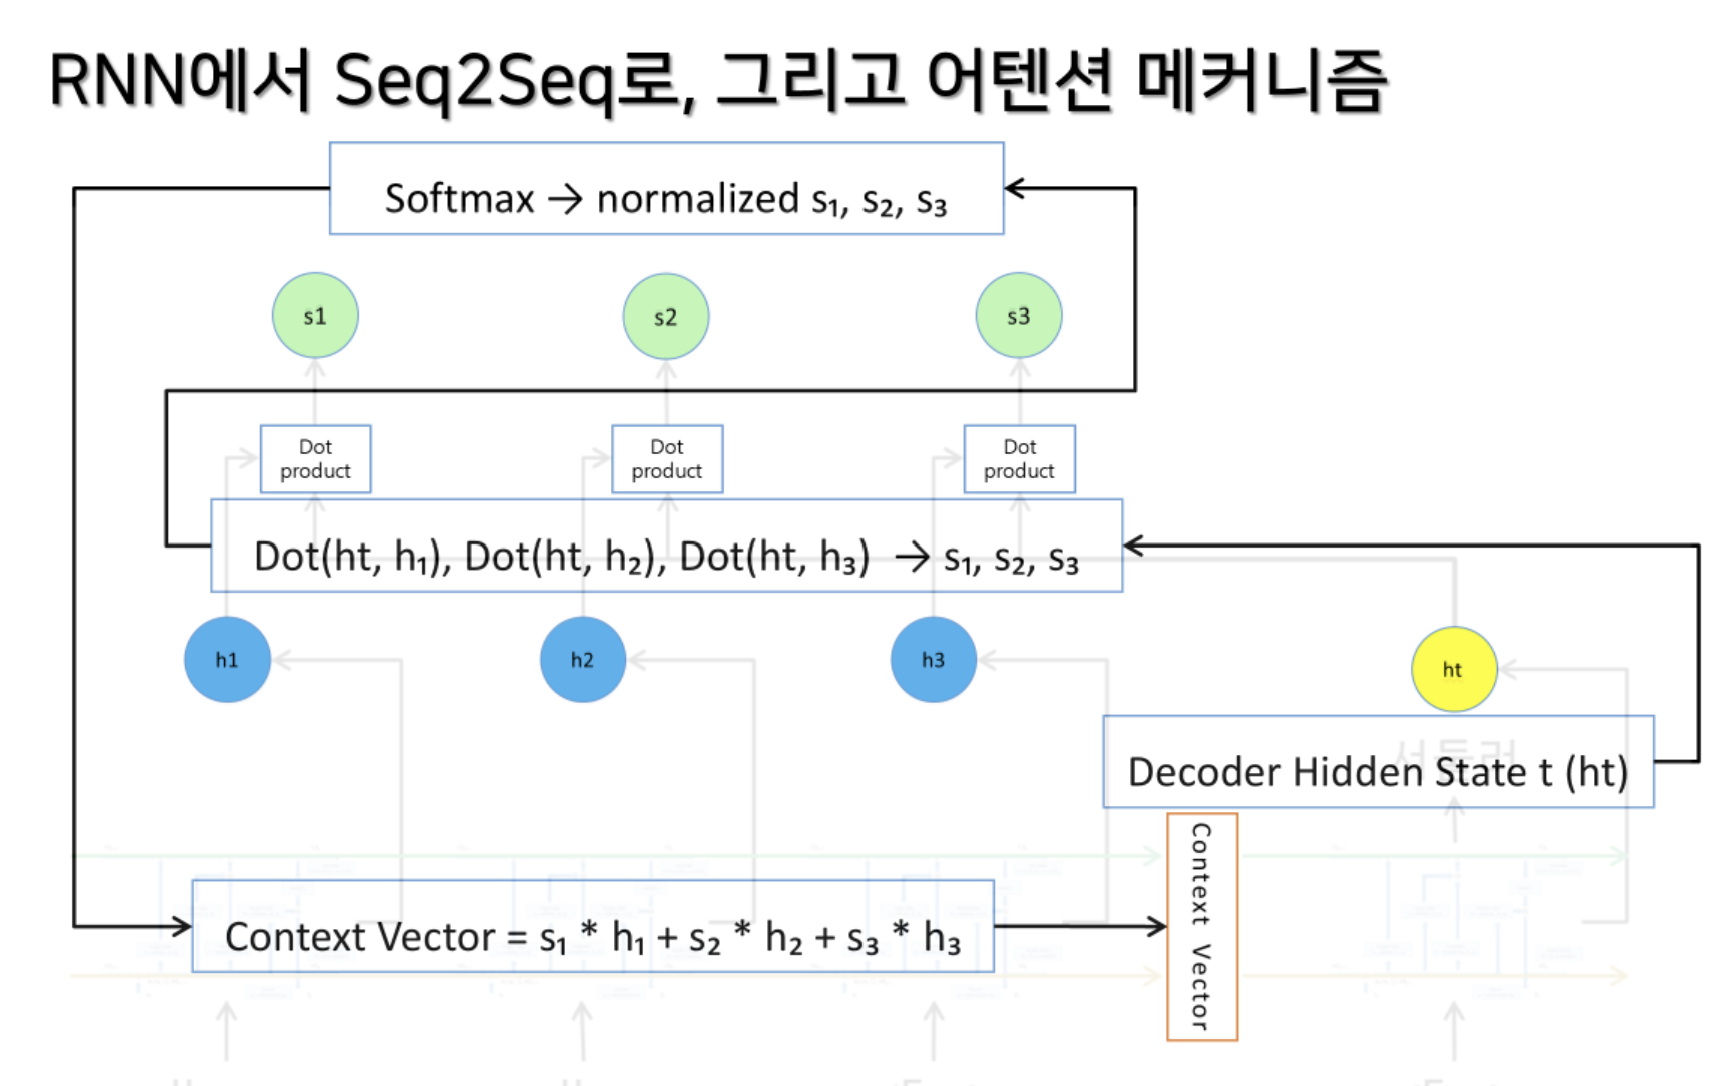

In [ ]:
# 디코더가 단어를 예측하는 매 시점(t)마다 새로운 컨텍스트 벡터(Context Vector)를 동적으로 계산한다

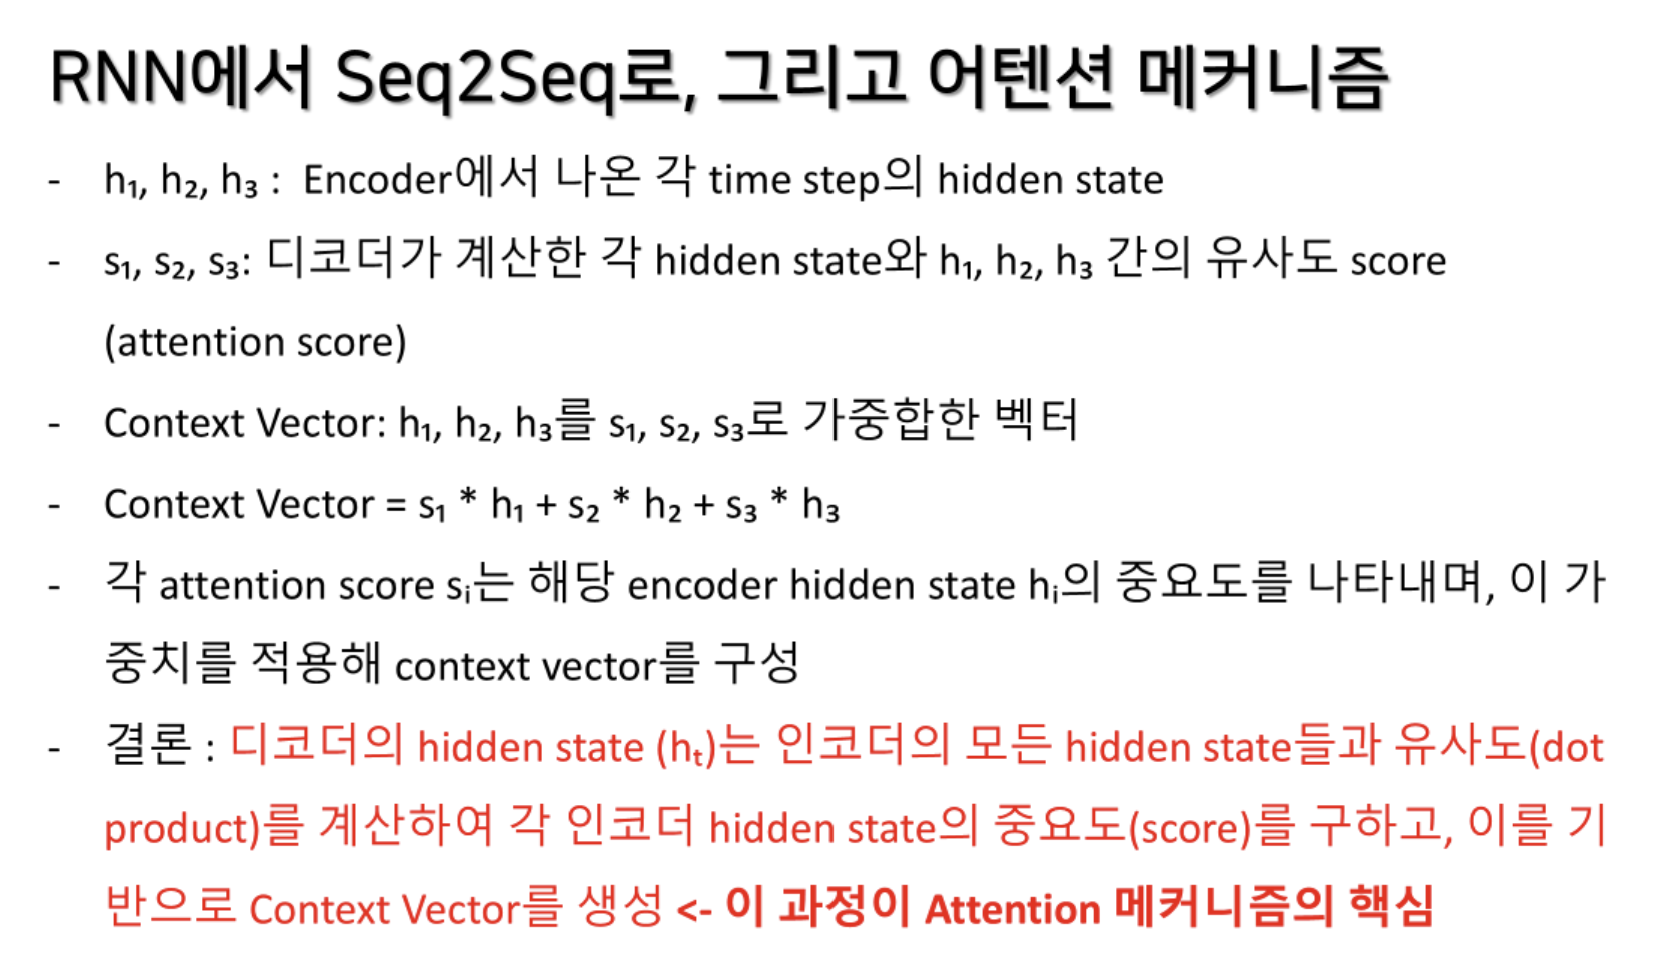

In [ ]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dot, Activation, Concatenate
from tensorflow.keras.callbacks import EarlyStopping

# 문자와 인덱스 매핑
chars = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
num_classes = len(chars)

char_to_index = {char : idx for idx, char in enumerate(chars)}
index_to_char = {idx : char for idx, char in enumerate(chars)}

# 데이터 생성 함수
def generate_data(num_samples):
    X = []
    y = []
    for _ in range(num_samples):
        sequence = np.random.choice(list(chars), 15)
        X.append([char_to_index[char] for char in sequence])
        y.append([char_to_index[char] for char in sequence[::-1]])
    return np.array(X), np.array(y)

# 데이터 생성
num_samples = 20000
X, y = generate_data(num_samples)

# 데이터 형태변화
X = X.reshape((X.shape[0], X.shape[1], 1)) # 샘플 수, 시퀀스의 길이, features
y = y.reshape((y.shape[0], y.shape[1], 1))

# 인코더 정의
encoder_inputs = Input(shape=(15, 1))
encoder = LSTM(128, return_sequences=True, return_state=True)
encoder_outputs, state_h, state_c = encoder(encoder_inputs)
encoder_states = [state_h, state_c]

# 디코더 정의
decoder_inputs = Input(shape=(15, 1))
decoder_lstm = LSTM(128, return_sequences=True, return_state=True)
decoder_outputs, state_h, state_c = decoder_lstm(decoder_inputs)

# 어텐션 메커니즘
attention = Dot(axes=[2, 2])([decoder_outputs, encoder_outputs]) # 내적 점수 계산
attention = Activation('softmax')(attention)
context = Dot(axes=[2, 1])([attention, encoder_outputs])

# 디코더 출려과 컨텍스트 결합
decoder_combined_context = Concatenate(axis=-1)([decoder_outputs, context])

# 출력 레이어
decoder_dense = Dense(num_classes, activation='softmax')
decoder_outputs = decoder_dense(decoder_combined_context)

# 모델 정의
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 입력 데이터와 타겟 데이터를 동일하게 맞춤
decoder_input_data = np.zeros_like(X)

# EarlyStopping 콜백 정의
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 모델 학습
model.fit([X, decoder_input_data], y, epochs=50, validation_split=0.2, callbacks=[early_stopping])

# 모델 검증 함수
def predict_reverse(input_sequence):
    input_sequence = np.array([char_to_index[char] for char in input_sequence]).reshape((1, 15, 1))
    decoder_input = np.zeros((1, 15, 1))
    predicted_sequence = model.predict([input_sequence, decoder_input])
    predict_indices = np.argmax(predicted_sequence, axis=-1).reshape((15,))
    return ''.join([index_to_char[idx] for idx in predict_indices])

# 검증용 문자열 리스트
test_strings = ["".join(np.random.choice(list(chars), 15)) for _ in range(30)]

# 실제 거꾸로 된 문자열 리스트
expected_outputs = [s[::-1] for s in test_strings]

# 모델 검증 및 정확도 계산
correct_predictions = 0
total_predictions = len(test_strings)

for i, test_string in enumerate(test_strings):
    predicted_output = predict_reverse(test_string)
    is_correct = predicted_output == expected_outputs[i]
    if is_correct:
        correct_predictions += 1
    print(f"입력 : {test_string}")
    print(f"예측된 출력 : {predicted_output}")
    print(f"실제 출력 : {expected_outputs[i]}")
    print(f"정확 여부 : {'맞음' if is_correct else '틀림'}\n")

accuracy = correct_predictions / total_predictions
print(f"정확도 : {accuracy * 100:.2f}")

In [ ]:
# 사과를 한입 베어 먹었다
# 어제일에 대해 사과했다
# '먹었다'라는 단어가 뒤따르는 것을 통해 앞서 나온 '사과' -> 과일
# '어제일'이라는 말이 앞서 나오는 것을 통해 뒤따르는 '사과' -> 행위

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Windows 한글 폰트(맑은 고딕) 설정 및 마이너스 깨짐 방지
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 단어와 임베딩 벡터 정의
word_embeddings = {
    '귤' : np.array([0, 6]),
    '딸기' : np.array([0, 5]),
    '수박' : np.array([1, 6]),
    '미소짓다' : np.array([6, 1]),
    '화내다' : np.array([6, 0]),
    '웃다' : np.array([5, 0]),
}

# 단어 임베딩 시각화
plt.figure(figsize=(4, 4))

for word, vec in word_embeddings.items():
    plt.scatter(*vec)
    plt.text(vec[0] + 0.1, vec[1], word)
plt.show()

In [ ]:
# 2. 단어들 사이의 내적 계산
import numpy as np

def dot_product(vec1, vec2):
    return np.dot(vec1, vec2)

print("귤 * 딸기 :", dot_product(word_embeddings['귤'], word_embeddings['딸기']))
print("귤 * 웃다 :", dot_product(word_embeddings['귤'], word_embeddings['웃다']))

# 내적의 값이 너무 클 경우, 비교하기 어렵기 때문에
# 코사인 유사도로 계산한다
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

words = list(word_embeddings.keys())
embedding_vectors = np.array(list(word_embeddings.values()))

# 계산
similarities = []
for v1 in embedding_vectors:
    row = []
    for v2 in embedding_vectors:
        row.append(cosine_similarity(v1, v2))
        similarities.append(row)

# 결과 출력
for i in range(len(words)):
    for j in range(len(words)):
        print(f"{words[i]} * {words[j]} 유사성 : {similarities[i][j]:.2f}")

In [ ]:
# 3. 단어 사이의 관계 수정하기
# 귤과 사과 : 귤 - 조사 '과' = 0, 귤 - 귤 = 1, 사과 - 귤 = W1
# 어제일을 사과 : 어제일 - 조사 '을' = 0, 어제일 - 사과 = W2

# 어텐션 모델은 주어진 문장들의 문장들의 문맥을 파악하면서, 그래프의 중앙에 위치한 '사과'라는 단어를
# 알맞은 위치로 이동시키는 역할을 수행한다.

# target_vector - vector : 현재 위치에서 목표 위치까지 가기 위한 방향과 거리
# learning_rate * similarity_value : 그 거리에서 실제로 이동할 비율(비중)을 곱해서 조절
# vector + (learning_rate * (target_vector - vector) * similarity_value) : 현재 위치 + 이동량 으로 '새로운 위치'
def update_vector(vector, target_vector, similarity_value, learning_rate):
    new_vector = vector + (learning_rate * (target_vector - vector) * similarity_value)
    return new_vector

# 기존 딕셔너리에 추가
word_embeddings['사과'] = np.array([3, 3]) #'사과'초깃값 추가
word_embeddings['과'] = np.array([0, 0]) # '과'벡터 추가

# 벡터 값 가져오기
귤 = word_embeddings['귤']
사과 = word_embeddings['사과']
과 = word_embeddings['과']

# '귤과 사과' 문장의 각 단어별 코사인 유사도
cosine_귤_사과 = cosine_similarity(귤, 사과)
cosine_과_사과 = cosine_similarity(과, 사과)

# 학습률 1의 예
learning_rate1 = 0.47

# '사과'벡터를 '귤'쪽으로 업데이트
print(f"업데이트 이전의 사과 벡터 (사과_?) : {사과}")
사과_과일 = update_vector(사과, 귤, cosine_귤_사과, learning_rate1)
print(f"업데이트된 사과 벡터 (사과_과일) : {사과_과일}")

In [ ]:
# 실습 : 특정 단어 벡터를, 단어 벡터 쪽으로 업데이트 한 후 결과를 시각화한다.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 초기 벡터 값 설정
사과 = np.array([3, 3])
귤 = np.array([0, 6])
과 = np.array([0, 0])
을 = np.array([0, 0])
어제일 = np.array([6, 0])

def cosine_similarity(v1, v2):
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    return dot_product / (norm_v1 * norm_v2)

def update_vector(vector, target_vector, similarity_value, learning_rate):
    new_vector = vector + (learning_rate * (target_vector - vector) * similarity_value)
    return new_vector

# '귤과 사과', 각 단어별 코사인 유사도
cosine_귤_사과 = cosine_similarity(귤, 사과)
cosine_과_사과 = cosine_similarity(과, 사과)

# 학습률 1
learning_rate1 = 0.47

# '사과' 벡터를 '귤' 쪽으로 업데이트
print(f"업데이트 이전의 사과 벡터(사과_?) : {사과}")
사과_과일 = update_vector(사과, 귤, cosine_귤_사과, learning_rate1)
print(f"업데이트 된 사과 벡터(사과_과일) : {사과_과일}")

# '어제일을 사과' 문장의 각 단어별 코사인 유사도
# 이미 한번 위치가 바뀐 '사과_과일'상태에서, '어제일'방향으로 업데이트를 진행
cosine_어제일_사과 = cosine_similarity(어제일, 사과_과일)
cosine_을_사과 = cosine_similarity(을, 사과_과일)

# 학습률 2
learning_rate2 = 1.11

# '사과' 벡터를 '어제일' 쪽으로 업데이트
사과_행위 = update_vector(사과_과일, 어제일, cosine_어제일_사과, learning_rate2)
print(f"업데이트 된 사과 벡터(사과_행위) : {사과_행위}")

# 단어 임베딩 시각화
word_embeddings = {
    "사과_?": 사과,
    "귤": 귤,
    "어제일": 어제일,
    "사과_과일": 사과_과일,
    "사과_행위": 사과_행위
}

plt.figure(figsize=(4, 4))
for word, vec in word_embeddings.items():
    plt.scatter(*vec)
    plt.text(vec[0] + 0.1, vec[1], word, fontsize=12)
plt.show()

In [ ]:
# AI가 문맥을 파악하는 법
# -> Attention is All You Need : 512개의 임베딩 값 사용해보기

# "커피 한잔 어때?"
# '커피', '한잔', '어때' -> (T1, T2, T3)
# 3개의 토큰으로 나눈 후, 각각의 토큰은 임베딩 결과 512개의 숫자로 표현

In [ ]:
import numpy as np

embedding_dict = {
    '커피' : np.random.rand(512),
    '한잔' : np.random.rand(512),
    '어때' : np.random.rand(512),
    'PAD' : np.zeros(512) # 패딩 벡터는 0으로 채운다
}

# 입력 문장
sentence = ['커피', '한잔', '어때']
max_len = 4 # 최대 문장 길이

tokens = sentence + ['PAD'] * (max_len - len(sentence)) # 파이썬 리스트 ['커피', '한잔', '어때', 'PAD]로 반복 만들어주기

# 토큰을 임베딩 벡터로 변환
embeddings = np.array([embedding_dict[token] for token in tokens])
print("임베딩 행렬의 형태:", embeddings.shape)

In [ ]:
# 토큰 당 512개씩 임베딩을 한 후, 어떻게 토큰끼리의 내적을 계산할건지
# (4, 512) * (512, 4) -> 이렇게 할 줄 알았는데(나)

# 512차원 임베딩 벡터를, 8개의 64차원 벡터로 나눈다 -> "헤드(Head)"

In [ ]:
num_heads = 8
head_dim = 512 // num_heads # 각 헤드의 차원

# 임베딩을 8개의 헤드로 분할
heads = np.split(embeddings, num_heads, axis=1)
print("각 헤드의 형태 :", heads[0].shape)

In [ ]:
# 분리된 헤드의 내적 구하기

# 첫번째 헤드 선택
head_1 = heads[0]

# 복사1, 복사2 생성
copy1 = head_1 # (4, 64)
copy2 = np.transpose(head_1) # (64, 4)

# 내적 계산
attention_scores = np.dot(copy1, copy2)
print("내적 결과 행렬의 형태 :", attention_scores.shape)

# 복사3 생성
copy3 = embeddings[:, :head_dim]

# 다시 (4, 64)형태로 변환
restore_head = np.dot(attention_scores, copy3) # (4, 4) * (4, 64)
print("복원된 헤드의 형태 :", restore_head.shape) # (4, 64)

# 8개의 모든 헤드
restored_haeds = []

for i in range(num_heads):
    head = heads[i]
    copy1 = head
    copy2 = np.transpose(head)
    attention_scores = np.dot(copy1, copy2)
    copy3 = embeddings[:, i * head_dim : (i+1) * head_dim]
    restored_head = np.dot(attention_scores, copy3)
    restored_haeds.append(restored_head)

# 모든 헤드를 결합하여 원래 차원으로 복원
final_output = np.concatenate(restored_haeds, axis=1)
print("최종 출력 행렬의 형태:", final_output.shape) 

In [ ]:
# 복사1 => 쿼리 : 헤드 형태 그대로 복사해서, 이 부분의 문맥을 파악하라는 질문(Query)
# 복사2 => 키 : 쿼리에 답을 하기 위한 단서(Key)
# 복사3 => 밸류 : 최종 답을 구하기 위한 값(Value)

In [ ]:
import numpy as np

embedding_dict = {
    '커피' : np.random.rand(512),
    '한잔' : np.random.rand(512),
    '어때' : np.random.rand(512),
    'PAD' : np.zeros(512) # 패딩 벡터는 0으로 채운다
}

# 입력 문장
sentence = ['커피', '한잔', '어때']
max_len = 4 # 최대 문장 길이

tokens = sentence + ['PAD'] * (max_len - len(sentence)) # 파이썬 리스트 ['커피', '한잔', '어때', 'PAD]로 반복 만들어주기

# 토큰을 임베딩 벡터로 변환
embeddings = np.array([embedding_dict[token] for token in tokens])
print("임베딩 행렬의 형태:", embeddings.shape)

# 쿼리, 키, 밸류 행렬 초기화
num_heads= 8
head_dim = 512 // num_heads
heads = np.split(embeddings, num_heads, axis=1)
queries = heads.copy()
keys = [np.transpose(head) for head in heads]
values = heads.copy()

print("쿼리 행렬의 형태:", queries[0].shape)
print("키 행렬의 형태:", keys[0].shape)
print("밸류 행렬의 형태:", values[0].shape)

In [ ]:
# 쿼리와 키의 내적값이 너무 클 경우, 계산이 복잡해지고 효율이 떨어진다
# 이를 방지하기 위해 적절한 크기로 조절하는 '스케일링'과정이 필요하다
# 이 과정을 위해 해당 헤드의 길이의 제곱근으로 내적 값을 나누어준다
# ex) 헤드의 길이 64 -> √64

In [16]:
# 스케일링 전
attention_scores = np.dot(queries[0], keys[0])
print("스케일링 전 어텐션 스코어") # 단어 간 유사도를 알기 위한 '내적' 값 구함
print(attention_scores)

# 스케일링을 위한 헤드 차원의 제곱근 계산
scaling_factor = np.sqrt(head_dim)

# 스케일링 후
scaled_attention_scores = attention_scores / scaling_factor
print("스케일링 후 어텐션 스코어")
print(scaled_attention_scores)

스케일링 전 어텐션 스코어
[[22.22544829 16.9918178  18.57061583  0.        ]
 [16.9918178  21.9884333  18.84550346  0.        ]
 [18.57061583 18.84550346 24.71545011  0.        ]
 [ 0.          0.          0.          0.        ]]
스케일링 후 어텐션 스코어
[[2.77818104 2.12397723 2.32132698 0.        ]
 [2.12397723 2.74855416 2.35568793 0.        ]
 [2.32132698 2.35568793 3.08943126 0.        ]
 [0.         0.         0.         0.        ]]


In [ ]:
# 각 원소의 값이 0 ~ 1 사이 값이 되고
# 행 기준, 모두 합했을 때 1이 되도록
# softmax 적용

In [ ]:
# 패딩 부분을 -∞로 채운 마스크 행렬 준비
mask = np.zeros_like(scaled_attention_scores)
mask[:, -1] = -np.inf # 마지막 열 패딩 처리
mask[-1, :] = -np.inf # 마지막 행 패딩 처리

# softmax 함수
def masked_softmax(x, mask):
    x_exp = np.exp(x - np.max(x, axis=-1, keepdims=True)) # 오버플로 방지
    x_exp = x_exp * (mask != -np.inf) # 마스크된 부분은 0으로 처리
    x_sum = np.sum(x_exp, axis=-1, keepdims=True) # 지수 값의 합 계산
    x_sum = np.where(x_sum == 0, 1, x_sum) # 분모가 0이 되는걸 방지하고자, 한 행의 모든 토큰이 0인 경우 -> 1로
    return x_exp / x_sum # softmax

# softmax 적용
attention_probs = masked_softmax(scaled_attention_scores, mask)
print("softmax 적용 후 어텐션 스코어")
print(attention_probs)

In [22]:
# 복원된 헤드를 저장할 리스트
restored_heads = []

for i in range(num_heads):
    query = queries[i]
    key = keys[i]
    value = values[i]
    
    # 내적 계산 후 스케일링
    attention_scores = np.dot(query, key) / scaling_factor

    # 패딩 처리
    padding_mask = (np.array(tokens) == 'PAD').astype(float)
    padding_mask = np.tile(padding_mask, (attention_scores.shape[0], 1))
    attention_scores = np.where(padding_mask, -np.inf, attention_scores) # (조건, 참일때 값, 거짓일 떄 값)

    # softmax 적용
    attention_weights = masked_softmax(attention_scores, padding_mask)

    # 밸류와의 곱셈
    restored_head = np.dot(attention_weights, value)
    restored_heads.append(restored_head)

# 모든 헤드를 결합하여 원래 차원으로 복원
final_output = np.concatenate(restored_heads, axis=1)
print("최종 출력 행렬의 형태 :", final_output.shape)

최종 출력 행렬의 형태 : [[0.49991667 0.78093439 0.49037688 ... 0.86758569 0.65983325 0.51816616]
 [0.40941704 0.70859423 0.50888777 ... 0.89325173 0.65121592 0.46352353]
 [0.49319982 0.77333179 0.52279559 ... 0.92100542 0.7745706  0.6912709 ]
 [0.45981174 0.74852858 0.50342045 ... 0.89099075 0.66586431 0.49836526]]
